# K5 Action Baseline

Characterize the new K5 recoloring action from random K43 colorings before introducing a neural policy. Each action ranks monochromatic K5 targets, evaluates all 1,022 nonmonochromatic replacement patterns for the most promising targets, and applies the best objective-ranked macro action.

This notebook deliberately performs **no neural training**. It establishes what the K5 action space itself can do. The previous single-edge PPO Phase 3 experiment is preserved separately.

In [1]:
# Imports and Project Paths

%matplotlib inline

from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np

from ramsey import (
    RGraph,
    RProblem,
    RRandomConstruction,
    RSearchState,
)
from ramsey.RK5Action import apply_k5_pattern
from ramsey.RK5Policy import (
    RK5PolicyConfig,
    select_greedy_k5_action,
)

project_root = Path.cwd().resolve()

if project_root.name == "notebooks":
    project_root = project_root.parent

if not (project_root / "ramsey").is_dir():
    raise RuntimeError(
        "Run this notebook from the RamseyNumber root or notebooks directory."
    )

In [2]:
# Experiment Configuration

RANDOM_SEED = 202_608_054
N_VERTICES = 43

NUMBER_OF_RUNS = 10
MAX_K5_ACTIONS = 128
REPORT_INTERVAL = 10

K5_TARGET_LIMIT = 10
MINIMUM_CHANGED_EDGES = 2
MAXIMUM_CHANGED_EDGES = 9
DANGER_DECAY = 0.25
USE_DANGER_REWARD = True

In [3]:
# Runtime, Problem, Graph, and K5 Policy

rng = np.random.default_rng(RANDOM_SEED)

graph_start = perf_counter()

problem = RProblem.r55(
    n_vertices=N_VERTICES,
)

graph = RGraph(problem)

graph_elapsed = perf_counter() - graph_start

construction = RRandomConstruction(rng)

k5_policy_config = RK5PolicyConfig(
    target_limit=K5_TARGET_LIMIT,
    minimum_changed_edges=MINIMUM_CHANGED_EDGES,
    maximum_changed_edges=MAXIMUM_CHANGED_EDGES,
    use_danger_reward=USE_DANGER_REWARD,
    danger_decay=DANGER_DECAY,
)

print("Problem:", problem)
print("Edges:", f"{graph.number_of_edges:,}")
print("K5s:", f"{graph.subgraph_index(5).clique_count:,}")
print("Graph construction:", f"{graph_elapsed:.3f} seconds")
print("Runs:", NUMBER_OF_RUNS)
print("Maximum K5 actions per run:", MAX_K5_ACTIONS)
print("K5 target limit:", K5_TARGET_LIMIT)
print("Changed-edge range:", f"{MINIMUM_CHANGED_EDGES}–{MAXIMUM_CHANGED_EDGES}")

Problem: RProblem(n_vertices=43, forbidden_clique_sizes=(5, 5))
Edges: 903
K5s: 962,598
Graph construction: 1.426 seconds
Runs: 10
Maximum K5 actions per run: 128
K5 target limit: 10
Changed-edge range: 2–9


In [4]:
# Run the Greedy K5 Macro-Action Experiment

run_results = []
all_changed_edge_counts = []
all_exact_rewards = []
all_objective_rewards = []

experiment_start = perf_counter()

for run_number in range(NUMBER_OF_RUNS):
    seed_coloring = construction.construct(graph)
    state = RSearchState(seed_coloring)

    initial_score = state.score
    best_score = state.score
    best_coloring = state.coloring_snapshot()

    score_trajectory = [state.score]
    seen_states = {state.colors.tobytes()}
    repeated_state = False

    run_start = perf_counter()

    for action_number in range(MAX_K5_ACTIONS):
        if state.score == 0:
            break

        selection = select_greedy_k5_action(
            state,
            k5_policy_config,
        )

        predicted_reward = selection.exact_reward

        actual_reward = apply_k5_pattern(
            state,
            selection.target_clique,
            selection.pattern_id,
        )

        if actual_reward != predicted_reward:
            raise RuntimeError(
                "Predicted and actual K5 rewards disagree: "
                f"{predicted_reward} versus {actual_reward}."
            )

        all_changed_edge_counts.append(
            selection.changed_edge_count
        )
        all_exact_rewards.append(actual_reward)
        all_objective_rewards.append(
            selection.objective_reward
        )

        score_trajectory.append(state.score)

        if state.score < best_score:
            best_score = state.score
            best_coloring = state.coloring_snapshot()

        state_key = state.colors.tobytes()

        if state_key in seen_states:
            repeated_state = True
            break

        seen_states.add(state_key)

        step_number = action_number + 1

        if step_number % REPORT_INTERVAL == 0:
            print(
                f"Run {run_number:2d} | "
                f"action={step_number:3d} | "
                f"score={state.score:5d} | "
                f"best={best_score:5d} | "
                f"exact={actual_reward:+4d} | "
                f"objective={selection.objective_reward:+10.3f} | "
                f"changed={selection.changed_edge_count}"
            )

    run_elapsed = perf_counter() - run_start
    actions_completed = len(score_trajectory) - 1

    run_result = {
        "run": run_number,
        "initial_score": initial_score,
        "final_score": state.score,
        "best_score": best_score,
        "best_coloring": best_coloring,
        "actions_completed": actions_completed,
        "repeated_state": repeated_state,
        "elapsed": run_elapsed,
        "trajectory": np.asarray(
            score_trajectory,
            dtype=np.int32,
        ),
    }

    run_results.append(run_result)

    print(
        f"Run {run_number:2d} COMPLETE | "
        f"initial={initial_score:5d} | "
        f"final={state.score:5d} | "
        f"best={best_score:5d} | "
        f"actions={actions_completed:3d} | "
        f"cycle={repeated_state} | "
        f"time={run_elapsed:.2f}s"
    )

experiment_elapsed = perf_counter() - experiment_start

Run  0 | action= 10 | score=  786 | best=  786 | exact= +18 | objective=   +44.145 | changed=2
Run  0 | action= 20 | score=  709 | best=  705 | exact=  +2 | objective=    +5.382 | changed=2
Run  0 | action= 30 | score=  659 | best=  651 | exact=  -8 | objective=   +20.271 | changed=2
Run  0 | action= 40 | score=  589 | best=  589 | exact=  +7 | objective=    -7.535 | changed=2
Run  0 | action= 50 | score=  561 | best=  560 | exact=  -1 | objective=   +14.687 | changed=2
Run  0 | action= 60 | score=  539 | best=  529 | exact=  -3 | objective=   +22.462 | changed=2
Run  0 | action= 70 | score=  519 | best=  519 | exact=  +2 | objective=   +27.044 | changed=2
Run  0 | action= 80 | score=  513 | best=  513 | exact=  +7 | objective=   +11.109 | changed=2
Run  0 | action= 90 | score=  502 | best=  492 | exact= -10 | objective=   -12.035 | changed=2
Run  0 | action=100 | score=  486 | best=  481 | exact=  -5 | objective=   +11.215 | changed=2
Run  0 | action=110 | score=  452 | best=  449 | e

In [5]:
# Experiment Summary

initial_scores = np.asarray(
    [result["initial_score"] for result in run_results],
    dtype=np.int32,
)
final_scores = np.asarray(
    [result["final_score"] for result in run_results],
    dtype=np.int32,
)
best_scores = np.asarray(
    [result["best_score"] for result in run_results],
    dtype=np.int32,
)

print("Runs:", len(run_results))
print("Mean initial score:", f"{initial_scores.mean():.2f}")
print("Mean final score:", f"{final_scores.mean():.2f}")
print("Mean best score:", f"{best_scores.mean():.2f}")
print("Minimum best score:", int(best_scores.min()))
print("Mean best reduction:", f"{(initial_scores - best_scores).mean():.2f}")
print("Improved runs:", f"{np.count_nonzero(best_scores < initial_scores)}/{len(run_results)}")
print("Repeated-state runs:", sum(result["repeated_state"] for result in run_results))
print("Total time:", f"{experiment_elapsed:.2f}s")
print("Mean run time:", f"{np.mean([result['elapsed'] for result in run_results]):.2f}s")

Runs: 10
Mean initial score: 1762.90
Mean final score: 457.60
Mean best score: 449.70
Minimum best score: 431
Mean best reduction: 1313.20
Improved runs: 10/10
Repeated-state runs: 0
Total time: 222.99s
Mean run time: 22.26s


In [6]:
# Action Statistics

changed_edge_counts = np.asarray(
    all_changed_edge_counts,
    dtype=np.int32,
)
exact_rewards = np.asarray(
    all_exact_rewards,
    dtype=np.int32,
)
objective_rewards = np.asarray(
    all_objective_rewards,
    dtype=np.float64,
)

print("Macro actions:", len(exact_rewards))
print("Positive exact reward:", f"{np.count_nonzero(exact_rewards > 0) / len(exact_rewards):.1%}")
print("Zero exact reward:", f"{np.count_nonzero(exact_rewards == 0) / len(exact_rewards):.1%}")
print("Negative exact reward:", f"{np.count_nonzero(exact_rewards < 0) / len(exact_rewards):.1%}")
print("Mean exact reward:", f"{exact_rewards.mean():+.2f}")
print("Mean objective reward:", f"{objective_rewards.mean():+.3f}")
print()
print("Changed-edge distribution:")

for changed_edges in range(1, 10):
    count = int(np.count_nonzero(changed_edge_counts == changed_edges))

    if count:
        print(
            f"  {changed_edges}: {count:,} "
            f"({count / len(changed_edge_counts):.1%})"
        )

Macro actions: 1280
Positive exact reward: 66.0%
Zero exact reward: 6.0%
Negative exact reward: 28.0%
Mean exact reward: +10.20
Mean objective reward: +33.284

Changed-edge distribution:
  2: 1,194 (93.3%)
  3: 21 (1.6%)
  4: 7 (0.5%)
  5: 12 (0.9%)
  6: 13 (1.0%)
  7: 8 (0.6%)
  8: 10 (0.8%)
  9: 15 (1.2%)


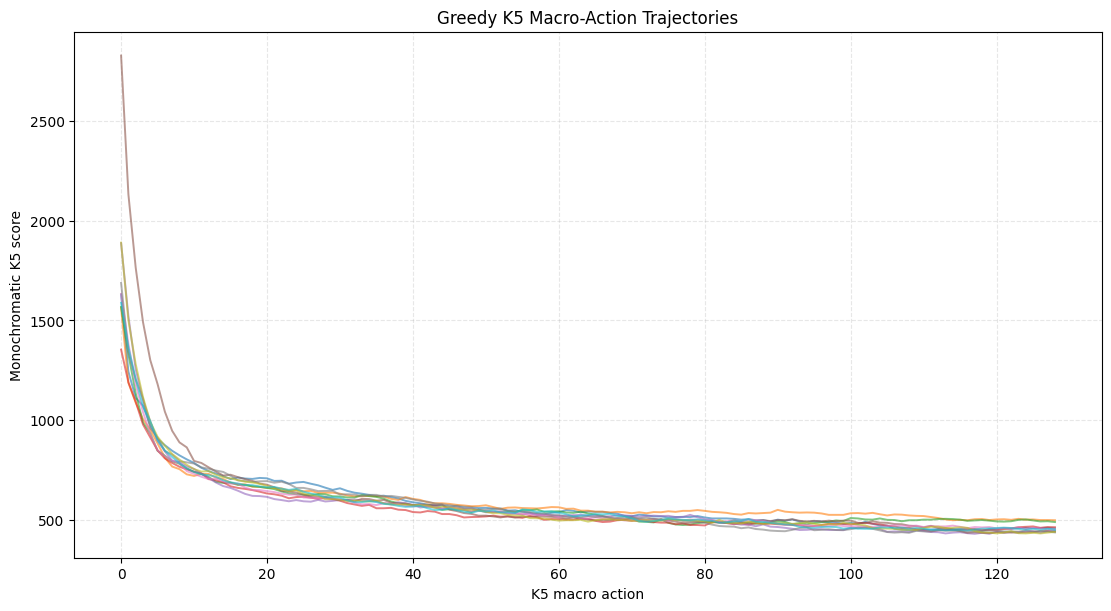

In [7]:
# Plot Score Trajectories

fig, axis = plt.subplots(
    figsize=(11, 6),
    constrained_layout=True,
)

for result in run_results:
    trajectory = result["trajectory"]

    axis.plot(
        np.arange(len(trajectory)),
        trajectory,
        alpha=0.60,
        linewidth=1.4,
    )

axis.set_xlabel("K5 macro action")
axis.set_ylabel("Monochromatic K5 score")
axis.set_title("Greedy K5 Macro-Action Trajectories")
axis.grid(linestyle="--", alpha=0.3)

plt.show()